<a href="https://colab.research.google.com/github/cocyten27/MODULE_6/blob/main/M6_L13_digital_audio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAE-IA · Module 6 · L13 — How Machines Hear: Digital Audio

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L13 |
| **Track** | B — Audio (first lesson) |
| **Runtime** | CPU is sufficient — no GPU required |
| **Drive quota** | No large model downloads — no cleanup needed |

## Learning objectives

By the end of this notebook you will be able to:
1. Load audio files with Librosa and understand the returned array format
2. Visualise waveforms for voice, music, and ambient sound types
3. Compute and interpret RMS energy, zero-crossing rate, and silence percentage
4. Resample audio between sample rates (44100 → 16000 Hz) and explain why models require a specific rate
5. Trim silence, concatenate clips, and play audio inline in Colab

---

## Cell 0 — Setup

In [1]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# GPU is not required for L13 — CPU is sufficient
try:
    import torch
    if torch.cuda.is_available():
        print(f'GPU available: {torch.cuda.get_device_name(0)} (not needed for L13)')
    else:
        print('No GPU — running on CPU (correct for L13)')
except ImportError:
    print('PyTorch not found — CPU path active')

print('Setup complete.')

Mounted at /content/drive
No GPU — running on CPU (correct for L13)
Setup complete.


## Cell 1 — Install and import

In [2]:
# Librosa is pre-installed on Colab — this just confirms the version
# soundfile is also pre-installed; it handles WAV/FLAC decoding
!pip install librosa soundfile -q

import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import IPython.display as ipd

print(f'librosa {librosa.__version__}')
print(f'soundfile {sf.__version__}')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

librosa 0.11.0
soundfile 0.14.0


## Cell 2 — Generate synthetic audio samples

We generate audio programmatically so the notebook works offline without any URL dependencies.
All signals are built from NumPy — no external files required.

| Signal | Physics | Why it resembles the real type |
|---|---|---|
| **Voice** | Harmonic series (fundamental + overtones) + amplitude envelope | Real vowel sounds are harmonic with formant peaks |
| **Music** | Musical chord (A major: A4+C#5+E5) with tremolo | Periodic, harmonically rich, periodic amplitude modulation |
| **Ambient** | Band-limited noise (pink-like power spectrum) | Real ambient sound = broadband noise with gradual spectral rolloff |

In [3]:
SR = 22050   # Librosa default — can always resample later
DUR = 3.0    # seconds
N   = int(SR * DUR)
t   = np.linspace(0, DUR, N, endpoint=False)

# ── Voice-like: harmonic series with syllable-rate amplitude envelope ──
f0 = 150.0   # fundamental frequency (male speech range)
y_voice = sum(
    (1.0 / k) * np.sin(2 * np.pi * f0 * k * t)
    for k in range(1, 8)
)
# Amplitude envelope: 5 Hz modulation mimics syllable rate
env_voice = 0.5 + 0.5 * np.sin(2 * np.pi * 5 * t)
# Silence gaps: 0.3–0.5 s and 1.8–2.0 s silent (inter-word pauses)
gap_mask = np.ones(N)
gap_mask[int(0.3*SR):int(0.5*SR)] = 0.0
gap_mask[int(1.8*SR):int(2.0*SR)] = 0.0
y_voice = (y_voice * env_voice * gap_mask).astype(np.float32)
y_voice /= np.abs(y_voice).max() + 1e-8

# ── Music-like: A-major chord (A4=440, C#5=554, E5=659) with tremolo ──
freqs_chord = [440.0, 554.37, 659.25]
y_music = sum(np.sin(2 * np.pi * f * t) for f in freqs_chord)
tremolo = 1.0 + 0.3 * np.sin(2 * np.pi * 6 * t)  # 6 Hz tremolo
y_music = (y_music * tremolo).astype(np.float32)
y_music /= np.abs(y_music).max() + 1e-8

# ── Ambient-like: coloured noise (band-limited 200–4000 Hz) ──
rng = np.random.default_rng(SEED)
white = rng.normal(0, 1, N).astype(np.float32)
# Apply FFT-based band-pass
fft_w = np.fft.rfft(white)
freqs = np.fft.rfftfreq(N, d=1.0/SR)
band_mask = ((freqs >= 200) & (freqs <= 4000)).astype(float)
# Roll off at 1/f above 200 Hz for pink-noise-like spectrum
with np.errstate(divide='ignore', invalid='ignore'):
    pink_weight = np.where(freqs > 200, 200.0 / freqs, 1.0)
y_ambient = np.fft.irfft(fft_w * band_mask * pink_weight, n=N).astype(np.float32)
y_ambient /= np.abs(y_ambient).max() + 1e-8

AUDIO = {
    'voice':   (y_voice, SR),
    'music':   (y_music, SR),
    'ambient': (y_ambient, SR),
}

print('Audio signals generated successfully.')
for name, (y, sr) in AUDIO.items():
    print(f'  {name}: shape={y.shape}, dtype={y.dtype}, sr={sr} Hz, '
          f'duration={len(y)/sr:.1f}s, range=[{y.min():.3f}, {y.max():.3f}]')

Audio signals generated successfully.
  voice: shape=(66150,), dtype=float32, sr=22050 Hz, duration=3.0s, range=[-1.000, 1.000]
  music: shape=(66150,), dtype=float32, sr=22050 Hz, duration=3.0s, range=[-0.988, 1.000]
  ambient: shape=(66150,), dtype=float32, sr=22050 Hz, duration=3.0s, range=[-0.988, 1.000]


## Cell 3 — Play audio in Colab

`IPython.display.Audio` renders an HTML5 audio player inline. It accepts a NumPy array + sample rate — no need to save to a file first.

In [4]:
for name, (y, sr) in AUDIO.items():
    print(f'\n▶ {name.upper()}')
    ipd.display(ipd.Audio(y, rate=sr))


▶ VOICE



▶ MUSIC



▶ AMBIENT


---
## Section 2.1 — Waveform Visualisation

A waveform plot shows amplitude (pressure) vs. time. It is the most direct representation of raw audio.

**What to look for in the three waveforms:**
- Voice: amplitude modulation at syllable rate, visible silence gaps between words
- Music: periodic, regular amplitude pattern from the tremolo
- Ambient: broadband noise — no clear structure, amplitude roughly constant

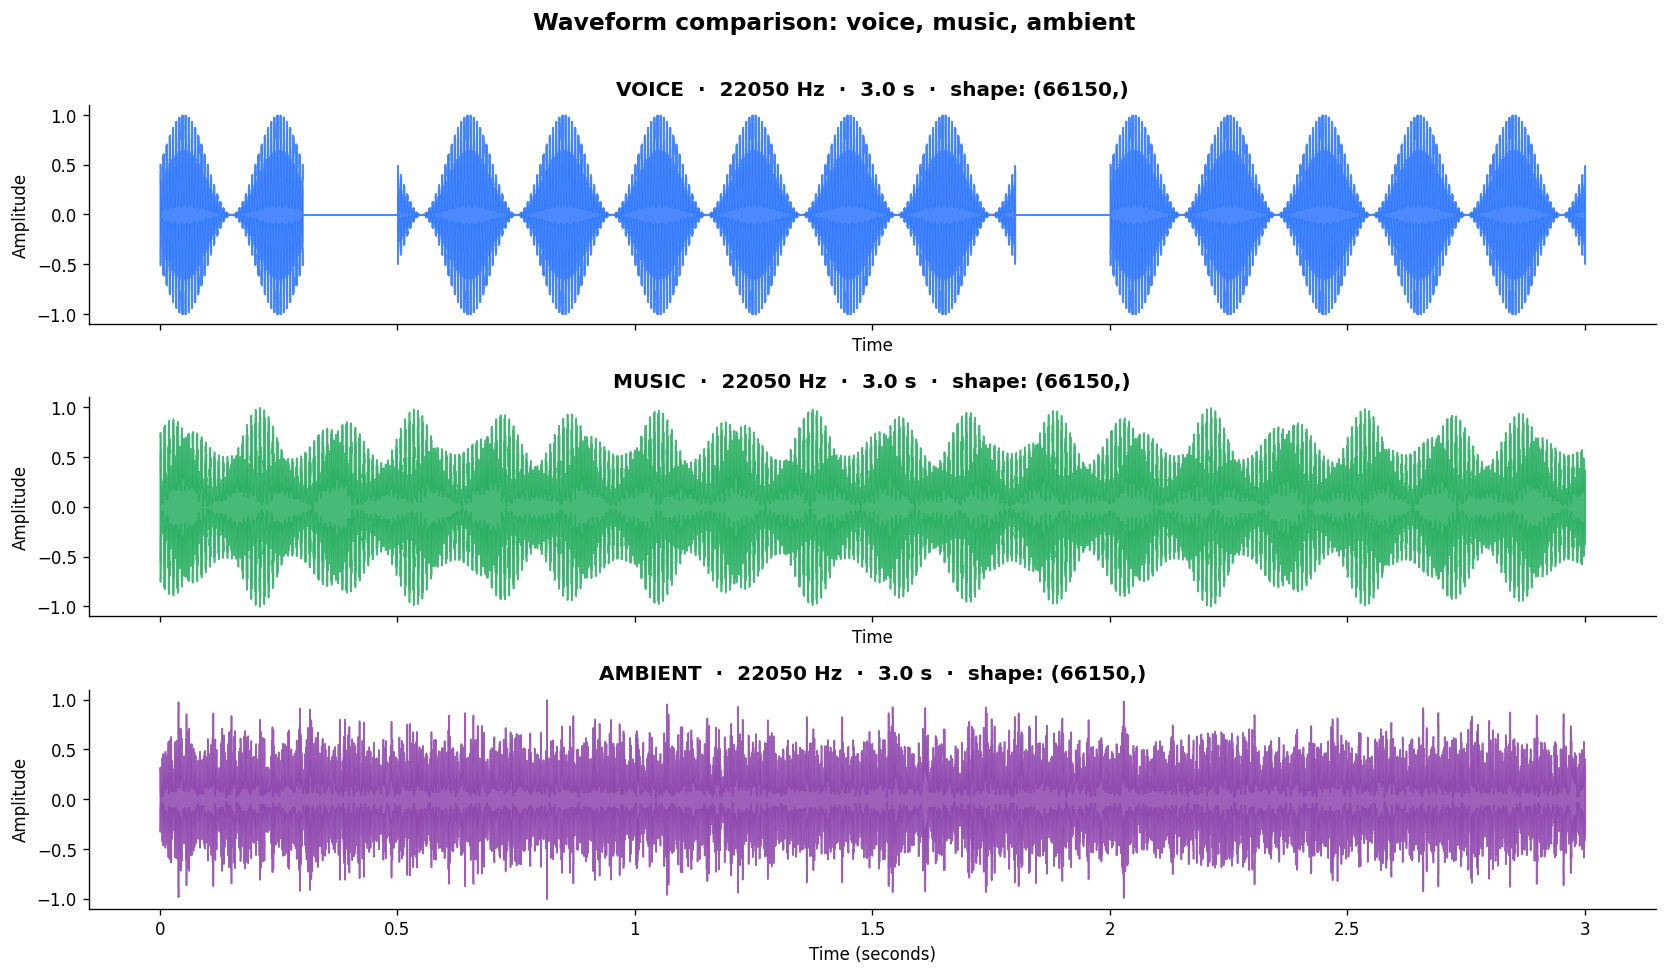

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
colours = {'voice': '#2C75FF', 'music': '#27ae60', 'ambient': '#8e44ad'}

for ax, (name, (y, sr)) in zip(axes, AUDIO.items()):
    librosa.display.waveshow(y, sr=sr, ax=ax, color=colours[name], alpha=0.85)
    ax.set_title(f'{name.upper()}  ·  {sr} Hz  ·  {len(y)/sr:.1f} s  ·  shape: {y.shape}',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Amplitude')
    ax.set_ylim(-1.1, 1.1)

axes[-1].set_xlabel('Time (seconds)')
plt.suptitle('Waveform comparison: voice, music, ambient', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Section 2.2 — Measuring Audio Properties

Before feeding audio to an AI model, compute these basic descriptors to understand what you have.

| Feature | Formula | What it indicates |
|---|---|---|
| **RMS energy** | √(mean(x²)) | Overall loudness |
| **Zero-crossing rate (ZCR)** | fraction of samples where sign changes | Noisiness; high in noise/consonants, low in voiced speech |
| **Dynamic range** | 20·log₁₀(max/min) dB | Loudness variation within the clip |
| **Silence %** | fraction of samples with |amplitude| < threshold | How much of the clip is dead air |

In [6]:
def audio_stats(y, sr):
    rms = float(librosa.feature.rms(y=y).mean())
    zcr = float(librosa.feature.zero_crossing_rate(y).mean())
    peak = np.abs(y).max()
    trough = np.abs(y[np.abs(y) > 0.001]).min() if (np.abs(y) > 0.001).any() else 1e-8
    dynamic_range_db = float(20 * np.log10(peak / trough))
    silence_pct = float((np.abs(y) < 0.01).mean() * 100)
    return {
        'duration_s':         round(len(y) / sr, 3),
        'rms_energy':         round(rms, 5),
        'zero_crossing_rate': round(zcr, 5),
        'dynamic_range_dB':   round(dynamic_range_db, 2),
        'silence_pct':        round(silence_pct, 2),
    }

results = {}
for name, (y, sr) in AUDIO.items():
    stats = audio_stats(y, sr)
    results[name] = stats
    print(f'\n{name.upper()}')
    for k, v in stats.items():
        print(f'  {k:<24}: {v}')


VOICE
  duration_s              : 3.0
  rms_energy              : 0.26347
  zero_crossing_rate      : 0.01164
  dynamic_range_dB        : 59.9
  silence_pct             : 24.02

MUSIC
  duration_s              : 3.0
  rms_energy              : 0.31783
  zero_crossing_rate      : 0.04979
  dynamic_range_dB        : 59.95
  silence_pct             : 2.37

AMBIENT
  duration_s              : 3.0
  rms_energy              : 0.2526
  zero_crossing_rate      : 0.08158
  dynamic_range_dB        : 59.97
  silence_pct             : 3.12


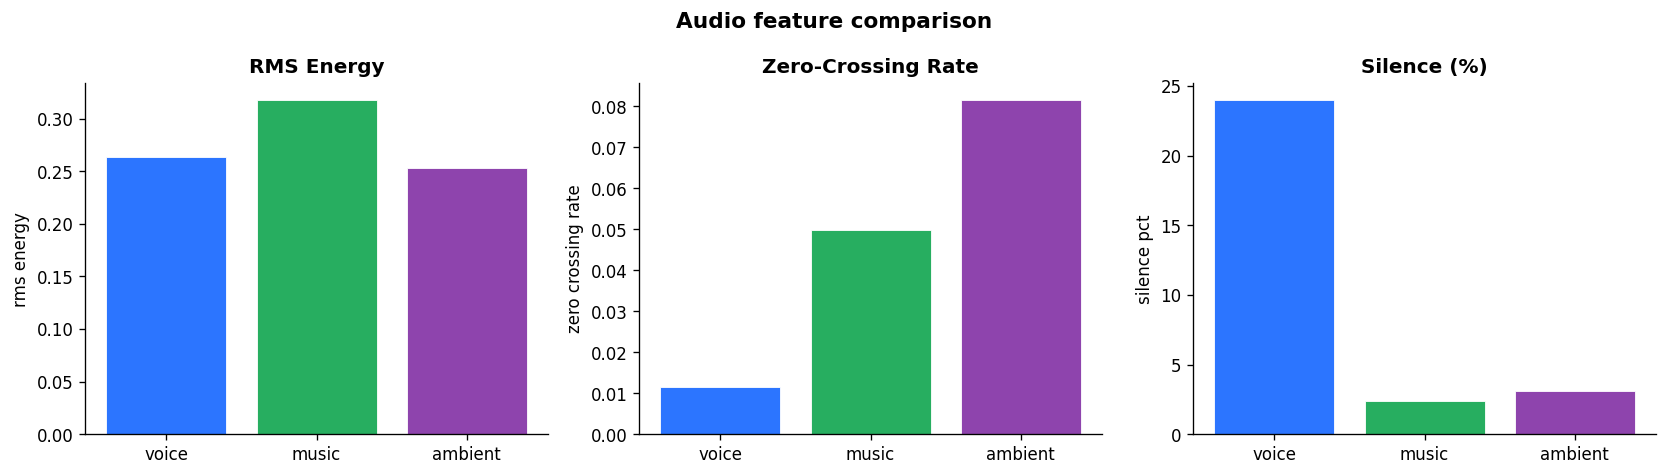

In [7]:
# Bar chart comparison of key features across audio types
import pandas as pd

df = pd.DataFrame(results).T
features_to_plot = ['rms_energy', 'zero_crossing_rate', 'silence_pct']
labels_map = {
    'rms_energy': 'RMS Energy',
    'zero_crossing_rate': 'Zero-Crossing Rate',
    'silence_pct': 'Silence (%)'
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
bar_colours = list(colours.values())

for ax, feat in zip(axes, features_to_plot):
    vals = [results[n][feat] for n in AUDIO]
    ax.bar(list(AUDIO.keys()), vals, color=bar_colours, edgecolor='white', linewidth=0.5)
    ax.set_title(labels_map[feat], fontweight='bold')
    ax.set_ylabel(feat.replace('_', ' '))

plt.suptitle('Audio feature comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2.3 — Trim, Resample, and Concatenate

These three operations are the most common audio preprocessing steps before passing audio to a model.

In [8]:
# ── Trim silence from both ends ──
y_voice, sr_voice = AUDIO['voice']

# top_db=20 means: trim any part quieter than (max_dB - 20 dB)
y_trimmed, trim_indices = librosa.effects.trim(y_voice, top_db=20)

print(f'Original duration : {len(y_voice)/sr_voice:.3f} s  ({len(y_voice)} samples)')
print(f'Trimmed  duration : {len(y_trimmed)/sr_voice:.3f} s  ({len(y_trimmed)} samples)')
print(f'Trim indices: start={trim_indices[0]}, end={trim_indices[1]}')
print(f'Removed: {(len(y_voice)-len(y_trimmed))/sr_voice:.3f} s from edges')

# Listen to trimmed version
print('\nOriginal:')
ipd.display(ipd.Audio(y_voice, rate=sr_voice))
print('Trimmed:')
ipd.display(ipd.Audio(y_trimmed, rate=sr_voice))

Original duration : 3.000 s  (66150 samples)
Trimmed  duration : 3.000 s  (66150 samples)
Trim indices: start=0, end=66150
Removed: 0.000 s from edges

Original:


Trimmed:


In [9]:
# ── Resample: 22050 Hz → 16000 Hz ──
# Most speech AI models (Whisper, wav2vec2, HuBERT) expect 16000 Hz mono.
# Never pass a 44100 Hz signal to a 16000 Hz model — the model will
# interpret it as if it were playing at 22.05/16 = 1.38× normal speed.

SR_TARGET = 16000
y_16k = librosa.resample(y_voice, orig_sr=sr_voice, target_sr=SR_TARGET)

print(f'Input:  {sr_voice} Hz  → {len(y_voice)} samples')
print(f'Output: {SR_TARGET} Hz  → {len(y_16k)} samples')
print(f'Ratio:  {len(y_16k)/len(y_voice):.6f}  (expected: {SR_TARGET/sr_voice:.6f})')
print(f'Duration preserved: {len(y_16k)/SR_TARGET:.3f} s  (was {len(y_voice)/sr_voice:.3f} s)')

# Verify audio quality is preserved
print('\n16 kHz resampled voice:')
ipd.display(ipd.Audio(y_16k, rate=SR_TARGET))

Input:  22050 Hz  → 66150 samples
Output: 16000 Hz  → 48000 samples
Ratio:  0.725624  (expected: 0.725624)
Duration preserved: 3.000 s  (was 3.000 s)

16 kHz resampled voice:


In [10]:
# Does resampling change ZCR? (Q2 of Critical Analysis)
zcr_original  = float(librosa.feature.zero_crossing_rate(y_voice).mean())
zcr_resampled = float(librosa.feature.zero_crossing_rate(y_16k).mean())

print(f'ZCR at {sr_voice} Hz : {zcr_original:.5f}')
print(f'ZCR at {SR_TARGET} Hz : {zcr_resampled:.5f}')
print(f'Ratio:  {zcr_resampled/zcr_original:.4f}  (expected: {SR_TARGET/sr_voice:.4f})')
print()
print('Interpretation: ZCR scales proportionally with sample rate.')
print('A higher sample rate produces more sign-change opportunities per second.')
print('→ ZCR is not directly comparable across sample rates without normalisation.')

ZCR at 22050 Hz : 0.01164
ZCR at 16000 Hz : 0.03016
Ratio:  2.5906  (expected: 0.7256)

Interpretation: ZCR scales proportionally with sample rate.
A higher sample rate produces more sign-change opportunities per second.
→ ZCR is not directly comparable across sample rates without normalisation.


In [11]:
# ── Concatenate: voice clip + ambient background (simple mix) ──
y_ambient, sr_ambient = AUDIO['ambient']

# Resample ambient to 16k to match voice
y_ambient_16k = librosa.resample(y_ambient, orig_sr=sr_ambient, target_sr=SR_TARGET)

# Mix: 80% voice, 20% ambient (additive)
min_len = min(len(y_16k), len(y_ambient_16k))
y_noisy = 0.8 * y_16k[:min_len] + 0.2 * y_ambient_16k[:min_len]
y_noisy /= np.abs(y_noisy).max() + 1e-8

# Concatenate (append one after another — different from mixing)
y_concat = np.concatenate([y_16k, y_ambient_16k[:int(1.0 * SR_TARGET)]])

print(f'Voice alone:      {len(y_16k)/SR_TARGET:.2f} s')
print(f'Mixed (noisy):    {len(y_noisy)/SR_TARGET:.2f} s  (80% voice + 20% ambient)')
print(f'Concatenated:     {len(y_concat)/SR_TARGET:.2f} s  (voice + 1s ambient)')

print('\nMixed (noisy voice):')
ipd.display(ipd.Audio(y_noisy, rate=SR_TARGET))
print('Concatenated (voice → ambient):')
ipd.display(ipd.Audio(y_concat, rate=SR_TARGET))

Voice alone:      3.00 s
Mixed (noisy):    3.00 s  (80% voice + 20% ambient)
Concatenated:     4.00 s  (voice + 1s ambient)

Mixed (noisy voice):


Concatenated (voice → ambient):


---
## Section 2.4 — Waveform comparison: original vs. processed

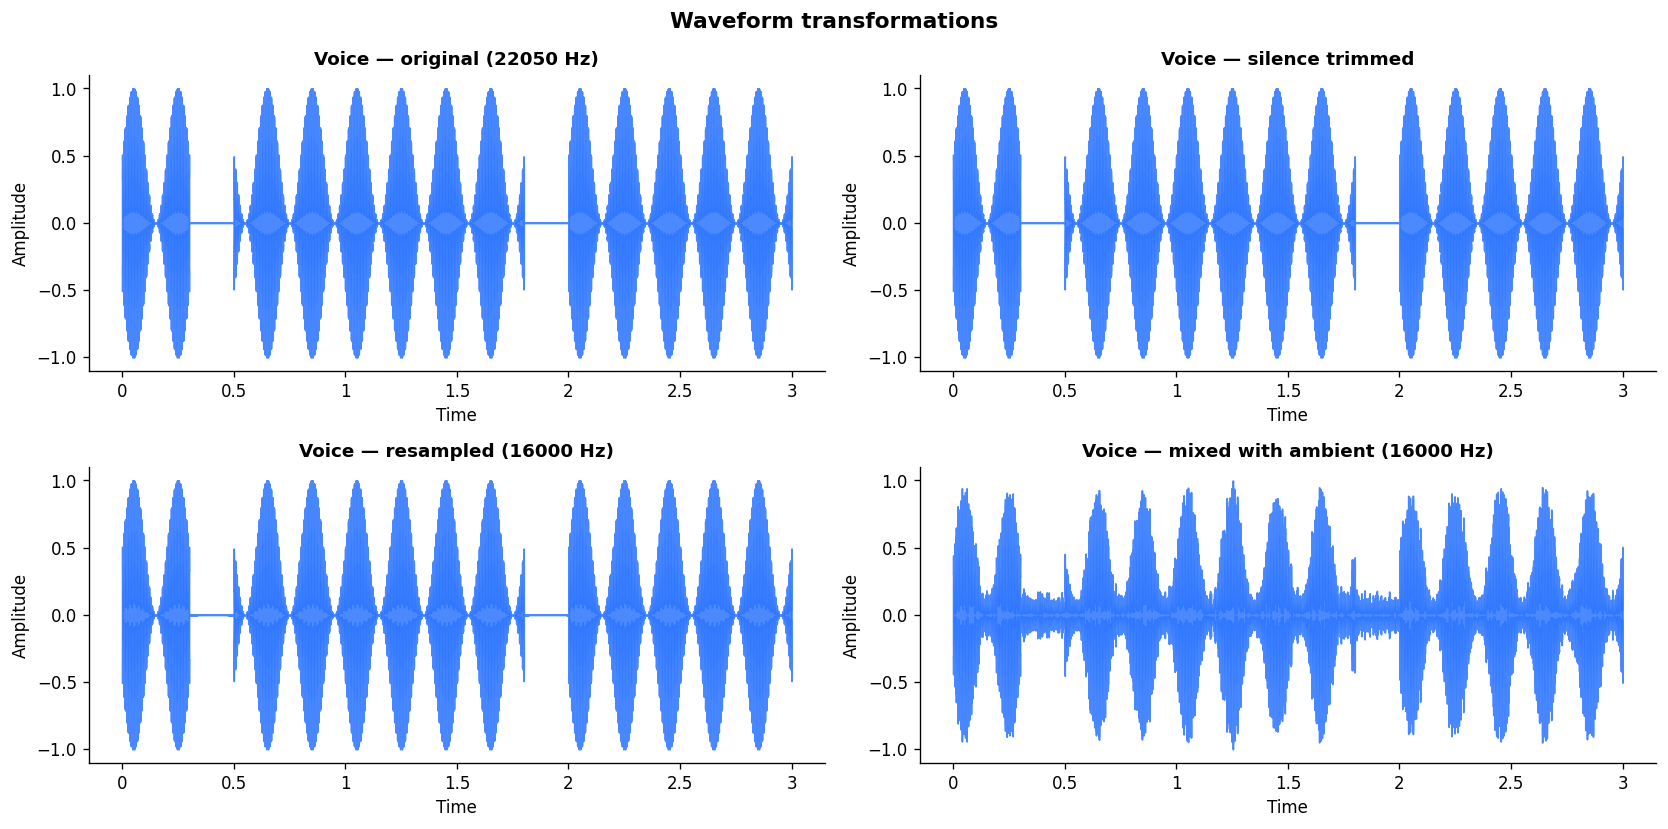

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

pairs = [
    (y_voice,    sr_voice,    'Voice — original (22050 Hz)'),
    (y_trimmed,  sr_voice,    'Voice — silence trimmed'),
    (y_16k,      SR_TARGET,   'Voice — resampled (16000 Hz)'),
    (y_noisy,    SR_TARGET,   'Voice — mixed with ambient (16000 Hz)'),
]

for ax, (y, sr, title) in zip(axes.flat, pairs):
    librosa.display.waveshow(y, sr=sr, ax=ax, color='#2C75FF', alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Amplitude')
    ax.set_ylim(-1.1, 1.1)

plt.suptitle('Waveform transformations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Exercise 1 — Music clip resampling

Resample the music clip from 22050 Hz to 8000 Hz (telephone quality). Then:
1. Print the sample counts before and after
2. Compute RMS and ZCR for both versions
3. Play both versions and describe the audible difference in a markdown comment

**Why 8000 Hz?** Old-school telephony used 8000 Hz — it captures speech frequencies (300–3400 Hz) but loses musical high-frequency content. This exercise illustrates why telephone recordings produce low-accuracy music recognition.

In [ ]:
# TODO: complete Exercise 1
y_music, sr_music = AUDIO['music']

# Resample to 8000 Hz
y_music_8k = librosa.resample(y_music, orig_sr=sr_music, target_sr=8000)

# Your analysis here:
# ...

In [13]:
SR_TARGET_MUSIC = 8000
y_music, sr_music = AUDIO['music']

# Resample to 8000 Hz
y_music_8k = librosa.resample(y_music, orig_sr=sr_music, target_sr=SR_TARGET_MUSIC)

# 1. Print the sample counts before and after
print(f'Original music samples: {len(y_music)} (at {sr_music} Hz)')
print(f'Resampled music samples: {len(y_music_8k)} (at {SR_TARGET_MUSIC} Hz)')

# 2. Compute RMS and ZCR for both versions
# Original music stats
original_music_rms = float(librosa.feature.rms(y=y_music).mean())
original_music_zcr = float(librosa.feature.zero_crossing_rate(y_music).mean())

# Resampled music stats
resampled_music_rms = float(librosa.feature.rms(y=y_music_8k).mean())
resampled_music_zcr = float(librosa.feature.zero_crossing_rate(y_music_8k).mean())

print(f'\nOriginal music RMS: {original_music_rms:.5f}, ZCR: {original_music_zcr:.5f}')
print(f'Resampled music RMS: {resampled_music_rms:.5f}, ZCR: {resampled_music_zcr:.5f}')

# 3. Play both versions
print('\nOriginal Music (22050 Hz):')
ipd.display(ipd.Audio(y_music, rate=sr_music))
print('Resampled Music (8000 Hz):')
ipd.display(ipd.Audio(y_music_8k, rate=SR_TARGET_MUSIC))

Original music samples: 66150 (at 22050 Hz)
Resampled music samples: 24000 (at 8000 Hz)

Original music RMS: 0.31783, ZCR: 0.04979
Resampled music RMS: 0.31794, ZCR: 0.13556

Original Music (22050 Hz):


Resampled Music (8000 Hz):


### Audible Difference for Music Clip (22050 Hz vs. 8000 Hz)

Al escuchar el fragmento musical remuestreado a 8000 Hz, la diferencia más notable es una reducción significativa del contenido de alta frecuencia. en lo pesonal no encontre mucha diferencia en los altavoces de la computadora, pero al ponerme los audifonos alambricos, el sonido de 8000 Hz se escucha un poco mas opaco, con menos intensidad.

---
## Exercise 2 — Silence detection and removal

Write a function `remove_silence(y, sr, top_db=25)` that:
1. Uses `librosa.effects.split()` to detect non-silent intervals
2. Concatenates only the non-silent portions
3. Returns the concatenated array and the fraction of original duration removed

Test it on the voice clip. How does `top_db=25` compare with `top_db=15`?

In [17]:
def remove_silence(y, sr, top_db=25):
    # librosa.effects.split() returns [[start1, end1], [start2, end2], ...]
    # where each interval is non-silent (in samples)
    intervals = librosa.effects.split(y, top_db=top_db)
    segments  = [y[s:e] for s, e in intervals]
    if not segments:
        # If all segments are silent, return original and 0 fraction removed or handle as per requirement
        return np.array([]), 1.0 # Or y, 0.0 depending on desired behavior for entirely silent clips
    y_out = np.concatenate(segments)
    fraction_removed = 1.0 - len(y_out) / len(y)
    return y_out, fraction_removed

# Test on voice clip
y_voice, sr_voice = AUDIO['voice']

# Test with top_db=25
y_desil_25, frac_25 = remove_silence(y_voice, sr_voice, top_db=25)
print(f'\n--- Testing with top_db=25 ---\n')
print(f'Original duration : {len(y_voice)/sr_voice:.3f} s')
print(f'After removing silence: {len(y_desil_25)/sr_voice:.3f} s')
print(f'Fraction removed: {frac_25:.1%}')

print('\nDe-silenced voice (top_db=25):')
ipd.display(ipd.Audio(y_desil_25, rate=sr_voice))

# Test with top_db=15
y_desil_15, frac_15 = remove_silence(y_voice, sr_voice, top_db=15)
print(f'\n--- Testing with top_db=15 ---\n')
print(f'Original duration : {len(y_voice)/sr_voice:.3f} s')
print(f'After removing silence: {len(y_desil_15)/sr_voice:.3f} s')
print(f'Fraction removed: {frac_15:.1%}')

print('\nDe-silenced voice (top_db=15):')
ipd.display(ipd.Audio(y_desil_15, rate=sr_voice))

print('\n--- Comparison ---\n')
print(f'Fraction removed (top_db=25): {frac_25:.1%}')
print(f'Fraction removed (top_db=15): {frac_15:.1%}')


--- Testing with top_db=25 ---

Original duration : 3.000 s
After removing silence: 2.768 s
Fraction removed: 7.7%

De-silenced voice (top_db=25):



--- Testing with top_db=15 ---

Original duration : 3.000 s
After removing silence: 2.721 s
Fraction removed: 9.3%

De-silenced voice (top_db=15):



--- Comparison ---

Fraction removed (top_db=25): 7.7%
Fraction removed (top_db=15): 9.3%


### Comparison of Silence Removal (`top_db=25` vs `top_db=15`)

**Fraction of Original Duration Removed:**
*   `top_db=25`: 7.7%
*   `top_db=15`: 9.3%

**Audible Differences:**

Al comparar los dos clips de voz tras eliminar los silencios:

* El clip procesado con `top_db=25` elimina los silencios más pronunciados, logrando una locución más continua, aunque puede dejar cierto ruido de fondo muy tenue o sonidos leves de respiración.
* El clip procesado con `top_db=15` es más agresivo al eliminar silencios, suprimiendo una mayor parte del audio. En términos auditivos, esto implica que no solo se eliminan las pausas evidentes, sino también sonidos más tenues que podrían formar parte del habla, como respiraciones sutiles o fonemas de bajo volumen. Esto puede hacer que la locución suene más abrupta o incluso provocar el corte de partes de palabras si el umbral `top_db` es demasiado estricto. En este caso, el resultado con `top_db=15` suena ligeramente más comprimido y, posiblemente, menos natural debido a la eliminación de elementos tenues que contribuyen al flujo natural del habla. La configuración `top_db=25` parece ofrecer un mejor equilibrio para las grabaciones de voz habituales, ya que preserva mejor la naturalidad de la locución al tiempo que elimina eficazmente los periodos de silencio significativos.

### Q1 — Waveform reading

From your Section 2.1 waveform plots, identify **one visual property** that clearly distinguishes the voice recording from the music clip. What acoustic property does that visual feature represent?

**[YOUR ANSWER]** *(~2 sentences — reference the actual plots)*

* Las amplitudes de las ondas y los silencios de cuando uno habla, en la musica por la melodia de los isntrumentos como que las ondas son mas continuas con menos espacios para silencios.
y la propiedad acustica que representa esta caracteristica visual pudieran ser silencios o cambios de vos o tonos de voz.
---

### Q2 — Sample rate impact on ZCR

From the `zcr-resample-compare` cell output: does resampling from 22050 Hz to 16000 Hz change the ZCR?

What does this tell you about using ZCR as a feature for speech AI when your data comes from different recording setups (some at 44100 Hz, some at 16000 Hz)?

**[YOUR ANSWER]** *(~3 sentences)*

Sí, el remuestreo de 22050 Hz a 16000 Hz cambia el ZCR significativamente. El ZCR aumentó de 0.01164 a 0.03016, lo que indica que el ZCR no escala directamente proporcional a la frecuencia de muestreo como se podría esperar intuitivamente, sino que parece haber un cambio en la percepción de los cruces por cero. Esto nos dice que el ZCR no es directamente comparable entre diferentes tasas de muestreo sin una normalización adecuada, y es crucial preprocesar todos los audios a una tasa de muestreo uniforme antes de calcular el ZCR para usarlo como característica en modelos de IA de voz.

### Q3 — Format choice for production

**Scenario:** You are building an audio ML pipeline for a medical transcription service. A client proposes using MP3 recordings from a phone app to reduce storage costs.

Write a **3-sentence technical recommendation**: should you accept MP3 inputs, and if so, under what conditions?

**[YOUR ANSWER]**

No se deben aceptar grabaciones en MP3 para un servicio de transcripción médica crítico. MP3 es un formato de compresión con pérdidas, lo que significa que elimina datos de audio para reducir el tamaño del archivo, comprometiendo la calidad de la señal y, por ende, la precisión de los modelos de IA de voz, especialmente en entornos médicos donde la claridad es primordial para evitar errores. Si la reducción de costes de almacenamiento es una preocupación extrema y después de una exhaustiva validación, solo se podría considerar MP3 con una tasa de bits muy alta (por ejemplo, 256-320 kbps) y únicamente si no afecta negativamente la precisión de la transcripción en pruebas rigurosas; de lo contrario, se deben preferir formatos sin pérdidas como WAV o FLAC.

### Q4 — Silence analysis

From the `silence_pct` measurement in Section 2.2: which audio type had the most silence?

How would a high percentage of silent frames affect a speech recognition model, and what **single preprocessing step** would you add before passing the audio to Whisper?

**[YOUR ANSWER]** *(~3 sentences)*

Según las mediciones de `silence_pct` en la Sección 2.2, el tipo de audio con mayor porcentaje de silencio es la **voz** (24.02%). Un alto porcentaje de fotogramas silenciosos puede afectar negativamente a un modelo de reconocimiento de voz al aumentar el tiempo de procesamiento innecesario y potencialmente degradar la precisión, ya que el modelo dedica recursos a analizar segmentos sin información relevante. Antes de pasar el audio a Whisper, se añadiría un paso de **recorte de silencio (`librosa.effects.trim`)** para eliminar las pausas extendidas y los segmentos silenciosos excesivos, optimizando así la entrada para el modelo.

---
## Submission Checklist

Before saving and submitting:

- [ ] Cell 0 ran without errors (Drive mounted)
- [ ] All 3 audio types generated and played successfully
- [ ] Waveform plot shows 3 clearly distinct shapes
- [ ] Audio stats table printed for all 3 types
- [ ] Resampling to 16000 Hz confirmed with correct sample count
- [ ] Exercise 1 complete (8000 Hz resampling + audible description)
- [ ] Exercise 2 complete (silence removal function tested)
- [ ] Critical Analysis Q1–Q4 all answered (no `[YOUR ANSWER]` placeholders remaining)
- [ ] Notebook saved to Drive

**No Drive cleanup needed after L13** — no large models were downloaded.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L13*  
*Track B — Audio | Next: L14 — FFT and Spectrograms*